In [1]:
# used my data: output.npz and output_valid.npz, which were generated by running the dismech_docker for original slinky.

In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(der_K.shape[0], 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        return 0.5 * jnp.sum(self.K * del_strain**2) + self.mlp(del_strain)


validate_model(Example)
final_model, train_history, valid_history = train_model(Example, train_file="output_original.npz", valid_file="output_original_valid.npz", n_epochs=500)

train.qs shape:  (11, 11)
valid.qs shape:  (11, 11)
Step 0    | Train: 2.12837e-04  | Valid: 1.90641e-04 
Step 10   | Train: 1.89661e-04  | Valid: 1.87676e-04 
Step 20   | Train: 1.36277e-04  | Valid: 1.25902e-04 
Step 30   | Train: 5.65958e-05  | Valid: 5.25897e-05 
Step 40   | Train: 2.23050e-05  | Valid: 2.09439e-05 
Step 50   | Train: 1.05262e-05  | Valid: 1.05882e-05 
Step 60   | Train: 3.92919e-06  | Valid: 4.38606e-06 
Step 70   | Train: 2.96609e-06  | Valid: 3.10982e-06 
Step 80   | Train: 2.48657e-06  | Valid: 2.92112e-06 
Step 90   | Train: 2.25760e-06  | Valid: 3.26168e-06 
Step 100  | Train: 2.18846e-06  | Valid: 3.48961e-06 
Step 110  | Train: 2.05859e-06  | Valid: 3.33080e-06 
Step 120  | Train: 1.93998e-06  | Valid: 3.04561e-06 
Step 130  | Train: 1.86316e-06  | Valid: 2.83916e-06 
Step 140  | Train: 1.81106e-06  | Valid: 2.75101e-06 
Step 150  | Train: 1.76754e-06  | Valid: 2.72851e-06 
Step 160  | Train: 1.72595e-06  | Valid: 2.71048e-06 
Step 170  | Train: 1.68837e-06

Text(0.5, 1.0, 'Training and Validation Loss')

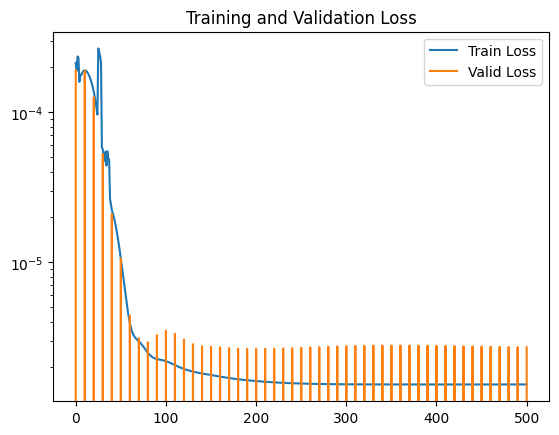

In [3]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="Train Loss")
plt.plot(valid_history, label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.title("Training and Validation Loss")

In [8]:
from util import TestCase

train = TestCase.from_npz("output_original.npz")
valid = TestCase.from_npz("output_original_valid.npz")
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [5]:
animate(valid.qs)

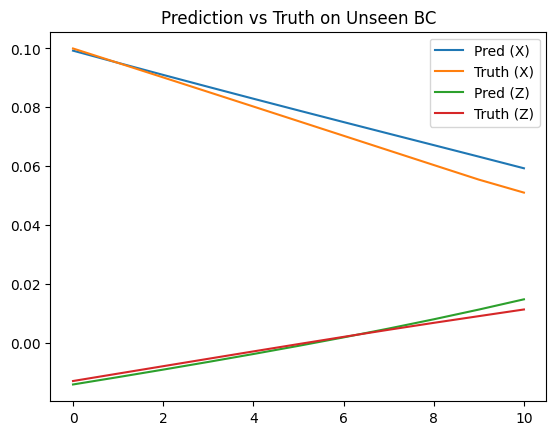

In [9]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()

In [10]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.2 0.  0. ]
final:  [ 0.1   0.   -0.05]
Validation BC:
init:  [0.2 0.  0. ]
final:  [0.1  0.   0.05]
